# Code : MLP

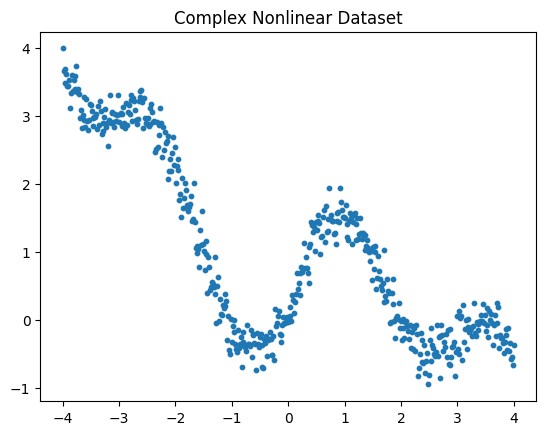

Epoch [100/1000], Loss: 0.2274
Epoch [200/1000], Loss: 0.0826
Epoch [300/1000], Loss: 0.0575
Epoch [400/1000], Loss: 0.0552
Epoch [500/1000], Loss: 0.0531
Epoch [600/1000], Loss: 0.0524
Epoch [700/1000], Loss: 0.0525
Epoch [800/1000], Loss: 0.0527
Epoch [900/1000], Loss: 0.0529
Epoch [1000/1000], Loss: 0.0529


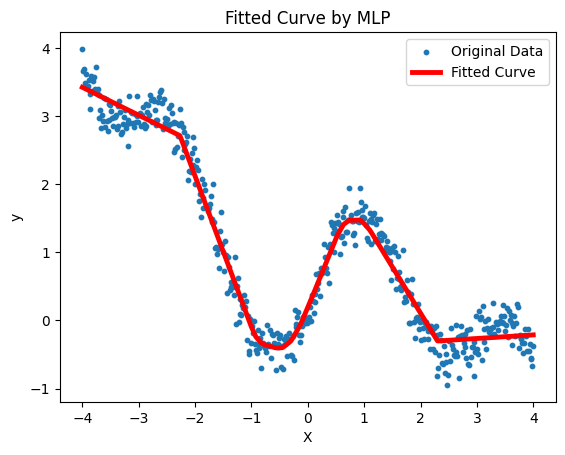

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ===================== 1. 构建人工数据集 =====================
# 假设真实的关系是 y = sin(2x) + log(abs(x) + 1) - 0.05x^3，并加入一些随机噪声

# 生成从-4到4的500个点
X = torch.linspace(-4, 4, 500)
# X.shape = (500)

X = X.unsqueeze(1)
# X.shape = (500, 1)

# 生成 y，加入随机噪声
y = torch.sin(2 * X) + torch.log(torch.abs(X) + 1) - 0.05 * X**3 + torch.randn(500, 1) * 0.2
# y.shape = (500, 1)

# 画出示例数据
plt.scatter(X.numpy(), y.numpy(), s=10)
plt.title("Complex Nonlinear Dataset")
plt.show()

# ===================== 2. 定义 MLP 模型 =====================
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        
        # 多层感知机，包含两层隐藏层
        self.mlp = nn.Sequential(
            nn.Linear(1, 64),  # 输入维度为1，隐藏层维度为64
            nn.ReLU(),         # 激活函数 ReLU
            nn.Linear(64, 64), # 隐藏层维度为64
            nn.ReLU(),         # 激活函数 ReLU
            nn.Linear(64, 1),  # 输出维度为1
        )

    def forward(self, x):
        return self.mlp(x)

# 实例化模型
model = MLPModel()

# ===================== 3. 定义损失函数和优化器 =====================
# 均方误差作为损失函数
criterion = nn.MSELoss()

# Adam 作为优化器
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 学习率 0.01

# ===================== 4. 训练模型 =====================
epochs = 1000  # 训练回合数
for epoch in range(epochs):
    # 使用模型预测输出
    predictions = model(X)
    
    # 计算损失
    loss = criterion(predictions, y)
    
    # 梯度清零，防止累积
    optimizer.zero_grad()
    
    # 计算梯度
    loss.backward()
    
    # 更新参数
    optimizer.step()

    # 打印训练过程中的损失值
    if (epoch + 1) % (epochs // 10) == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# ===================== 5. 可视化结果 =====================
# 使用训练好的模型预测
predicted = model(X)

# 原始数据
plt.scatter(X.numpy(), y.numpy(), label='Original Data', s=10)

# 预测数据
plt.plot(X.numpy(), predicted.detach().numpy(), color='red', label='Fitted Curve', linewidth=3.5)

plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title("Fitted Curve by MLP")
plt.show()
